In [1]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys 

import analysis_utils
sys.path.append("../")

import checkpoint

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Loaded following datasets
val dataloader (n=22912),
test dataloader (n=22912)
Loading model that has completed (or started) 20 of 20 epochs
	batch size: 25
	number of steps:146,640
	best val loss achieved: 1.1439
MLC specs:
	1,400,606 parameters
	3 encoder layers
	3 decoder layers
	8 attention heads
	128 embedding size
	512 feedforward layer sizes
	gelu activation function
	p=0.1 dropout
Training information for model trained with 3 study examples:
Best Validation Loss: 1.144
Best Validation Accuracy: 0.378


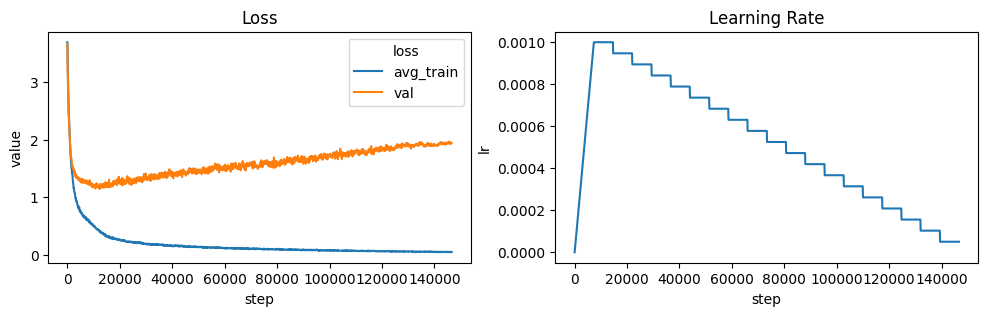

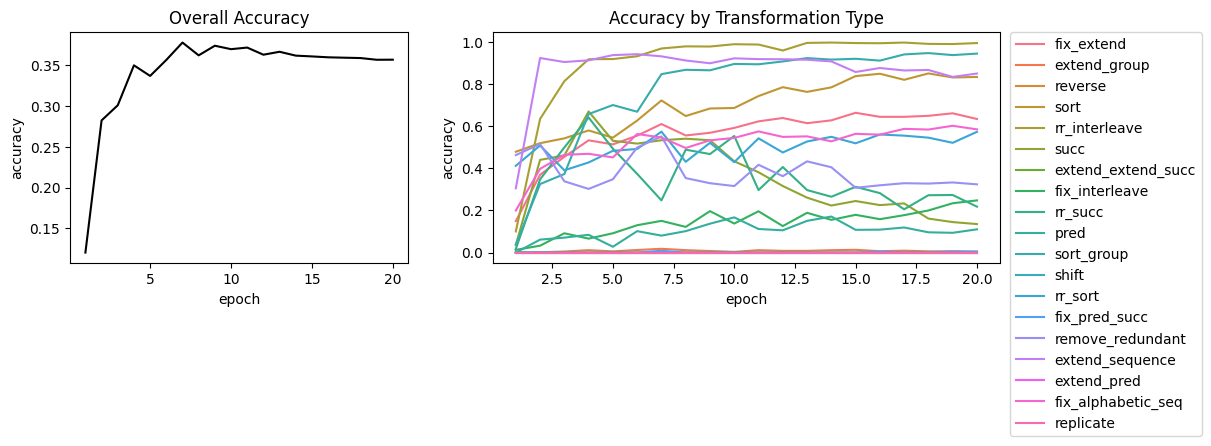

In [2]:
cp = checkpoint.CheckPoint("../models/MLC_dallstudy1_nep20.pt", device=DEVICE)
val, test = cp.load_dataloaders("../data/all_transformations_study1", val_batch_size=1000, use_datasets=["val","test"])
model = cp.load_model()
analysis_utils.training_information(cp, val, "Training information for model trained with 3 study examples:")

### Generalization types

In [ ]:
val_acc = pd.DataFrame(cp.checkpoint["val_accuracy"])
val_acc = pd.melt(val_acc, id_vars=['epoch'], value_vars=val.dataset.transformation_types, var_name="transformation", value_name="accuracy")

In [ ]:
import generate_data
generalization_types = dict()
type_0 = {trans[1].__name__: 0 for trans in list(generate_data.ALL_TRANSFORMATIONS.items())[:10]}
generalization_types.update(type_0)
type_2 = {trans[1].__name__: 2 for trans in list(generate_data.ALL_TRANSFORMATIONS.items())[10:16]}
generalization_types.update(type_2)
type_3 = {trans[1].__name__: 3 for trans in list(generate_data.ALL_TRANSFORMATIONS.items())[16:]}
generalization_types.update(type_3)
for key, value in generalization_types.items():
    print(key, value)
val_acc["generalization_type"] = val_acc["transformation"].apply(lambda x: generalization_types[x])

In [30]:
val_acc["generalization_type"] = val_acc["transformation"].apply(lambda x: generalization_types[x])

In [32]:
val_final_acc = val_acc[val_acc.epoch == val_acc.epoch.max()]

In [36]:
val_final_acc.groupby("generalization_type")["accuracy"].mean()

generalization_type
0    0.563749
2    0.138513
3    0.000000
Name: accuracy, dtype: float64

In [ ]:
#  Transformations present in both data splits
# 1.	Extend Sequence (a b c d -> a b c d e)
# 2.	Successor (a b c d -> a b c e)
# 3.	Predecessor (b c d e -> a c d e)
# 4.	Remove Redundant letter (a b b c d -> a b c d)
# 5.	Fix alphabetic sequence (a b c w e -> a b c d e)
# 6.	Sort (a d c b e -> a b c d e)
# 7.	Sort + Group (aa dd cc bb ee -> aa bb cc dd ee)
# 8.	Remove redundant + Interleave (a x b x b x c x d -> a x b x c x d)
# 9.	Remove Redundant + successor (a b b c d -> a b c e)
# 10.	Fix alphabetic sequence + extend sequence (a b c w -> a b c d e)
#
# Transformations only present in validation/ test splits:
# 11. Remove Redundant + Sort (a d d c b e -> a b c d e)
# 12. Extend Sequence + Predecessor (b c d e -> a c d e f)
# 13. Fix alphabetic sequence + Interleave (a f b f c f w f e -> a f b f c f d f e)
# 14. Extend sequence + Group (aa bb cc dd -> aa bb cc dd ee)
# 15. Extend Sequence + Extend Sequence + Successor (a b c d -> a b c d e g)
# 16. Fix alphabetic Sequence + Predecessor + Successor (a b c w e -> a a c d f)
# 17. Reverse (a b c d -> d c b a)
# 18. Shift (a b c d -> e f g h)
# 19. Replicate (a b c d -> a b c d a b c d)